## Measure empirical PSFs on resampled NIRCam Images

In [5]:
%matplotlib inline
import os
import glob
import numpy as np
from galfitx.source_detection import SExtractor_HDR
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import shutil
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.io import ascii
from astropy.visualization import simple_norm
from pathlib import Path
from typing import Optional, Tuple, List
import os
import sys

# ── import plotting helpers ───────────────────────────────────────────────────
import sys
from pathlib import Path as Path2
path = Path2('~/code_package').expanduser()
sys.path.append(str(path))
import matplotlib.pyplot as plt
from my_astro_tools import my_im_show,set_plot_style
set_plot_style()    

In [6]:
sci_dir = '/RS2423/JWST/grism/data/direct_image/'
sci_files = sorted(glob.glob(os.path.join(sci_dir, '*resample.fits')))
print(sci_files)
print(len(sci_files))

['/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F200W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F356W_mosaic_resample.fits']
3


In [7]:
sci_file = sci_files[0]
band = sci_file.split('/')[-1].split('_')[-3]
print(sci_file, band)
out_path = "/RS2423/JWST/grism/data/direct_image/sextractor/"+band+"/"
psf_out_path = "/RS2423/JWST/grism/data/direct_image/psfex/"
os.makedirs(out_path, exist_ok=True)
os.makedirs(psf_out_path, exist_ok=True)

/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits F115W


In [8]:
with fits.open(sci_file) as hdul:
    hdul.info()
    hdr = hdul[1].header
    data = hdul[1].data  # or hdul['SCI'].data
    coverage_mask = ((data == 0) | np.isnan(data))  # True for pixels with zero coverage or NaN
    print(f"Shape: {data.shape}")
    print(f"Min: {np.nanmin(data):.6f}")
    print(f"Max: {np.nanmax(data):.6f}")
    print(f"Mean: {np.nanmean(data):.6f}")
    print(f"Median: {np.nanmedian(data):.6f}")
    print(f"Std: {np.nanstd(data):.6f}") 

Filename: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        75   (21000, 12000)   float32   
  2  ERR           1 ImageHDU        10   (21000, 12000)   float32   
  3  CON           1 ImageHDU        10   (21000, 12000, 12)   int32   
  4  WHT           1 ImageHDU         9   (21000, 12000)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (21000, 12000)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (21000, 12000)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (21000, 12000)   float32   
  8  HDRTAB        1 BinTableHDU    536   384R x 263C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 24A, 40A, 15A, 3A, 9A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 39A, 10A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 10A, 23A, 5A, D, D, D, D, D, D, D, D, 7A, 6A, 5A, 1A, 5A, 

In [9]:
print(np.sum(np.isfinite(data)))
print(np.sum(np.isnan(data)))

220847429
31152571


In [10]:
hdr

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                21000                                                  
NAXIS2  =                12000                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
MJD-BEG =    59813.49840402778 / [d] exposure start time in MJD                 
MJD-AVG =    59814.00297424527 / [d] exposure mid-point in MJD                  
MJD-END =      59814.963254375 / [d] exposure end time in MJD                   
TDB-BEG =    59813.50224648655 / [d] TDB time of exposure start in MJD          
TDB-MID =   59814.0068551944

In [11]:
pixel_sr = hdr['PIXAR_SR']
pixel_scale = np.sqrt(hdr['PIXAR_A2']) #arcsec/pixel
mag_zeropoint = -2.5 * np.log10((u.MJy / u.sr * (pixel_sr*u.sr**2) / (3631 * u.Jy)).cgs.value)
print(mag_zeropoint,pixel_scale) 

28.96704130984462 0.02


In [12]:
print(f"Coverage mask: {np.sum(coverage_mask)}")

Coverage mask: 31152571


#### SExtractor catalog

In [ ]:
outtab, outsegm = SExtractor_HDR(
    filename=sci_file,
    file_ext=1,
    catalog_name=("coldcat_"+band, "hotcat_"+band, "outcat_"+band),
    segmap_name=("coldseg_"+band+".fits", "hotseg_"+band+".fits", "outseg_"+band+".fits"),
    path=out_path,
    back_type=(True, True),
    back_value=(0.0, 0.0),
    detect_thresh=(3, 2),
    back_size=(128, 32),
    mag_zeropoint=mag_zeropoint,
    pixel_scale=pixel_scale,
    fwhm_arcsec=0.13,
    verbose=True,
    coverage_mask = coverage_mask,
    nnw_sex = '/home/zhanghan/sextractor/config/default.nnw'
)



**********Cold Detection**********

Source Extraction Begins.......
detection image: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits


Weight Image Preprocessing Finished
  weight_type = NONE


Automatic Background Estimation and Subtraction Finished
  background size = 128
  background filter size = 3


Detection Finished
  detect_minarea = 5
  detect_thresh = 3
  threshold (above background) = 0.036176733672618866
Found 25970 sources.


Deblending skipped.


Cleaning skipped.


There are 25970 objects in the catalog.

obj_crowded [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fals

In [10]:
idx1 =  (outtab['elongation'] < 1.5) 
idx2 =  (outtab['class_star'] > 0.0) 
idx3 =  (outtab['combined_flags'] < 2) 
print(np.sum(idx1), np.sum(idx2), np.sum(idx3))

15111 69953 69953


In [11]:
outtab[0:5]

label,xcentroid,ycentroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,background_centroid,elongation,ellipticity,fwhm,kron_radius,flux_radius,ra,dec,cxx,cxy,cyy,gini,segment_area,mag_auto,class_star,combined_flags,global_rms
,,,,,,,pix2,pix,pix,deg,,,,,,,,,,,,pix,pix,pix,,,1 / pix2,1 / pix2,1 / pix2,,pix2,,,,
int64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float32
1,4407.223562739713,7.3445650495856984,4406,4408,7,8,2.0,0.7115434053796384,0.4541346930094374,14.808603787632158,0.7698383491483517,0.06569002568721771,0.08021609485149384,0.0,0.14590612053871155,0.017053878,0.18442831107116195,0.02822693132315707,0.0,1.5668113807038562,0.3617610822109477,1.4055458449189626,3.5,1.0267918579595974,15.061527494146231,28.08568776065972,2.1628612629052473,-1.4201528203868552,4.661035093070342,0.09955764097245046,5.0,30.8025,0.019272752112033026,0,0.012058912
2,4417.943837904968,7.810677048213776,4417,4419,7,9,6.0,0.7826372549599571,0.7680968269780509,45.45862004696569,0.19186543539755635,0.06154673174023628,0.13658344745635986,0.0,0.4928262010216713,0.02953818,0.45017972449449006,0.04389405901452442,0.0,1.0189304622427786,0.0185787577702905,1.825930111453678,3.5,1.0551554964589902,15.061563365197072,28.085637241228426,1.6642946653753647,-0.06238869354323621,1.66329580820372,0.19348495577503666,9.0,29.8336,0.019448669405849554,0,0.012058912
3,4439.054932742627,7.451808804586546,4437,4441,7,8,5.0,1.4021329875563635,0.4976322714318554,-0.2755086571170527,0.9349001324573407,0.044106148183345795,0.09826037287712097,0.0,0.3716851472854614,0.026964547,0.5074318051985164,0.0434009000554871,0.0,2.8176086400545435,0.6450891064911548,2.4773864068190954,3.5,1.6908595391952634,15.061640626396493,28.085541778009137,0.5087345801722988,0.03394292684641033,4.038072852430676,0.153102941030257,10.0,29.7036,0.019345569913791615,0,0.012058912
4,4448.136700853339,7.408036403538077,4447,4450,7,8,3.0,0.9666291163018818,0.482112925123815,-6.541417114830598,0.8667419290643334,0.07129783928394318,0.10117417573928833,0.0,0.24644987285137177,0.020886648,0.3787075726155777,0.03486096846788907,0.0,2.0049848612825194,0.5012431169378831,1.7986299259854566,3.5,1.3367770448116445,15.06167328965837,28.08550036220616,1.1121839317312778,0.7316119306481497,4.260371226180028,0.12122682844053599,7.0,30.0213,0.01927817494979381,0,0.012058912
5,4453.466907382463,7.980350848761749,4453,4454,7,9,4.0,0.8141954542666924,0.49889101826197213,-89.6835358816248,0.7902837113160014,0.04086374118924141,0.07228312641382217,0.0,0.22819173336029053,0.024117824,0.3512183290896935,0.03901178431764598,0.0,1.6320106485443902,0.3872589000004921,1.5899887985566454,3.693295640983853,1.1821955566992732,15.061689358756443,28.085474170416504,4.017726363667846,0.027719008840484175,1.5085673080512585,0.18059691651895568,6.0,30.1031,0.01929706649209708,0,0.012058912


In [38]:
from psfex_helper import build_input_ldac, psfex_config
from galfitx.create_psf import run_psfex

In [39]:
# ========================================================================
# User-defined parameters - modify these for your data
# ========================================================================
sci_image = sci_file           # Path to science image
file_ext = 1
catalog_file = out_path+"outcat_"+band            # SExtractor catalog (ASCII)
seg_file = out_path+"outseg_"+band+".fits"           # SExtractor segmentation map
template_file = "/home/zhanghan/output_assoc_temp.cat"  # Template LDAC file

output_dir = psf_out_path # Output directory
output_ldac = psf_out_path + "psfex_" + band +".cat"           # Output LDAC catalog name

# Star selection criteria
mag_bright_limit = 19.0            # Bright magnitude limit
mag_faint_limit = 21.0             # Faint magnitude limit

# Cutout parameters
cutout_size = 71                  # Size of star cutouts (pixels)

# PSFEx configuration parameters
psf_sampling = 0.5                 # Sampling step (0.0 = auto)
psf_size = (141, 141)              # Output PSF size
sample_minsn = 100                  # Minimum S/N for star selection

# Image metadata 
fwhm_arcsec = 0.1                 # Approximate FWHM in arcsec
mag_zeropoint = mag_zeropoint               # Magnitude zero-point
ref_pixel_scale = pixel_scale       # Pixel scale (arcsec/pixel)

In [40]:
sci = fits.open(sci_image)[file_ext].data
seg = fits.open(seg_file)[0].data
print(sci.shape, seg.shape)

(12000, 21000) (12000, 21000)


In [41]:
# ========================================================================
# Step 1: Build LDAC catalog for PSFEx
# ========================================================================
print("=" * 60)
print("Step 1: Building LDAC catalog for PSFEx")
print("=" * 60)

build_input_ldac(
    sci_image=sci_image,
    catalog_file=catalog_file,
    seg_file=seg_file,
    output_ldac=output_ldac,
    file_ext = file_ext,
    mag_bright_limit=mag_bright_limit,
    mag_faint_limit=mag_faint_limit,
    cutout_size=cutout_size,
    save_cutouts=True,
    #crossmatch=True,
    cutouts_dir=os.path.join(output_dir, "star_cutouts_"+band),
    template_file=template_file,
    fwhm_arcsec=fwhm_arcsec,
    mag_zeropoint=mag_zeropoint,
    ref_pixel_scale=ref_pixel_scale,
    star_coords_path=os.path.join(output_dir, f"star_coords_{band}.txt")
)

# ========================================================================
# Step 2: Generate PSFEx configuration file
# ========================================================================
print("\n" + "=" * 60)
print("Step 2: Generating PSFEx configuration file (constant PSF)")
print("=" * 60)

config_file = os.path.join(output_dir, "config"+band+".psfex")
psfex_config(
    output_config=config_file,
    psf_sampling=psf_sampling,
    psf_size=psf_size,
    sample_autoselect=True,
    sample_fwhmrange="0.5, 4",
    sample_minsn=sample_minsn,
    psfvar_degrees=0,
    outcat_name=os.path.join(output_dir, "psfex_cat_"+band+".txt")  # Constant PSF
)

# ========================================================================
# Step 3: Run PSFEx
# ========================================================================
print("\n" + "=" * 60)
print("Step 3: Running PSFEx")
print("=" * 60)

psf_file = run_psfex(
    catalog=output_ldac,
    config=config_file,
    output_dir=output_dir,
)

print("\n" + "=" * 60)
print("PSFEx workflow completed successfully!")
print(f"PSF model saved to: {psf_file}")
print(f"Output directory: {output_dir}")
print("=" * 60)

Step 1: Building LDAC catalog for PSFEx
523 sources satisfy stellar criteria.
523 sources satisfy stellar criteria.
523 out of 523 stars are fully within the image and have been cut out.
Cropped star images saved to /RS2423/JWST/grism/data/direct_image/psfex/star_cutouts_F115W/
SNR values: [2.20602913e+01 3.51616211e+01 1.43758373e+01 6.47928095e+00
 2.13708382e+01 3.52273102e+01 8.84804840e+01 4.84559479e+01
 2.18536606e+01 7.61824493e+01 5.46462746e+01 4.96299248e+01
 2.19397259e+01 2.88367615e+01 1.10175073e+03 6.51549759e+01
 1.01397393e+04 2.38403564e+02 3.32736359e+01 8.06692047e+01
 7.17053909e+01 6.21384506e+01 5.76191406e+02 1.31691125e+03
 3.50573463e+01 4.50975914e+01 5.12966881e+01 5.46679192e+01
 4.85387268e+01 3.03246784e+01 4.64387787e+02 1.58924280e+03
 6.21083260e+01 3.23122673e+01 4.35083084e+01 4.46365700e+01
 3.11529297e+02 9.58395233e+01 6.26514015e+01 7.28277206e+01
 3.56346252e+02 5.98442802e+01 6.88027115e+01 4.02939746e+03
 3.60256920e+01 2.87772179e+01 2.55938

> 
----- PSFEx 3.17.1 started on 2026-07-19 at 22:10:03 with 1 thread

> 
----- 1 input catalogues:
psfex_F115W.cat     :  "no ident        "    1 extension     523 detections

> Initializing contexts...
> Reading data from psfex_F115W...
> Computing final PSF model for psfex_F115W...
   filename      [ext] accepted/total samp. chi2/dof FWHM ellip. resi. asym.
> Computing diagnostics for psfex_F115W...
psfex_F115W                 21/23      0.50  12.75   2.36  0.01  0.04  0.13
> Saving PSF model and metadata for psfex_F115W...
> 
> All done (in 0.0 s)


PSF model written to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W.psf
PSF FITS saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_psf.fits
Radial profile saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_radial_profile.png
FWHM = 2.882171299596024

PSFEx workflow completed successfully!
PSF model saved to: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W.psf
Output directory: /RS2423/JWST/grism/data/direct_image/psfex/


In [42]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

psf_file = psf_out_path + "psfex_"+band+"_psf.fits"

with fits.open(psf_file) as hdul:
    hdul.info()
    psf_data = hdul[0].data  

Filename: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_psf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (71, 71)   float64   


In [43]:
from photutils.psf import fit_fwhm
print("="*60)
print(f"FWHM for empirical PSF: {band}")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stacked_psfex = fit_fwhm(psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stacked_psfex} arcsec")

FWHM for empirical PSF: F115W
pixel scale = 0.02 arcsec/pixel
PSF FWHM = 0.05764342599192048 arcsec


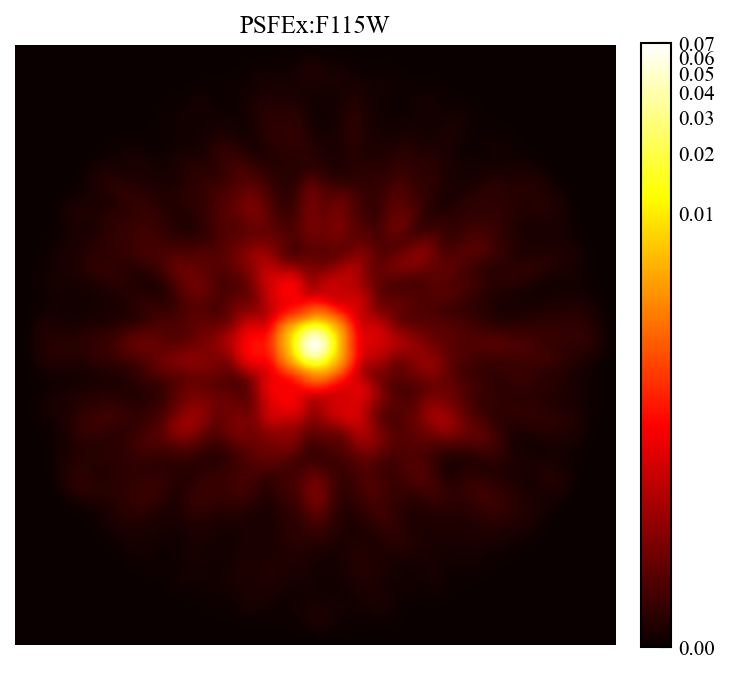

In [44]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
norm = simple_norm(psf_data, stretch='log')
im = ax.imshow(psf_data, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
ax.set_title("PSFEx:"+band)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [45]:
# PSFEx output — NUMBER is the 1-indexed row in the input LDAC
psfex_cat = ascii.read(os.path.join(output_dir, "psfex_cat_"+band+".txt"))

# star_coordinates.txt has columns: x, y, original_label
coords = np.loadtxt(os.path.join(output_dir, "star_coordinates_"+band+".txt"))

matched_ids = []
for row in psfex_cat:
    x_psf, y_psf = row['X_IMAGE'], row['Y_IMAGE']
    dx = np.abs(coords[:, 0] - x_psf)
    dy = np.abs(coords[:, 1] - y_psf)
    dist = np.sqrt(dx**2 + dy**2)
    match_idx = np.argmin(dist)
    if dist[match_idx] < 1.0:
        matched_ids.append(int(coords[match_idx, 2]))

print("Stars used by PSFEx (original IDs):", matched_ids)

Stars used by PSFEx (original IDs): [7651, 8894, 8909, 9230, 9252, 9589, 9758, 10462, 22384, 11187, 11691, 12013, 13016, 13396, 13494, 13788, 13956, 14167, 14298, 18377, 19888]


In [46]:
outtab = ascii.read(catalog_file)

In [47]:
psf_outtab = outtab[np.isin(outtab['label'], matched_ids)]

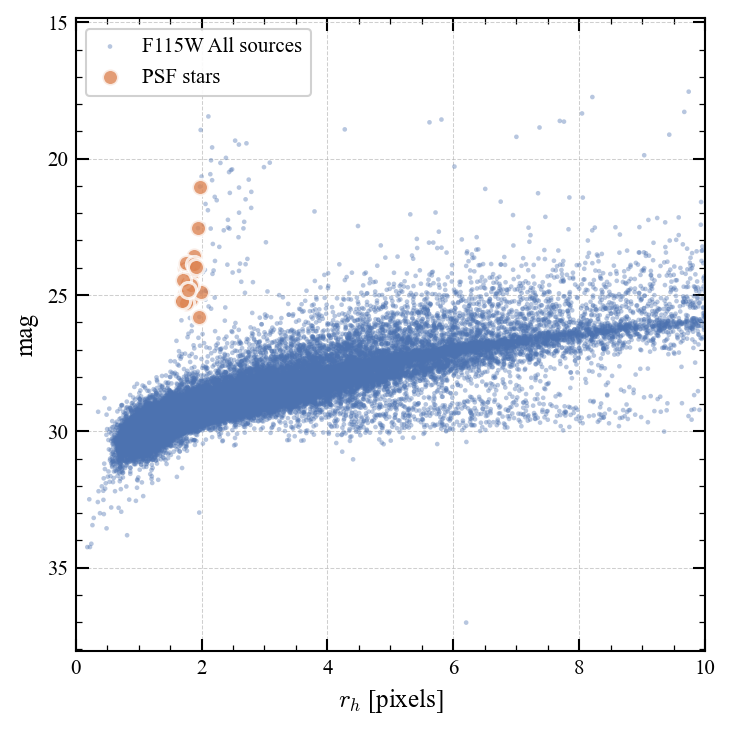

In [48]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.scatter(outtab['flux_radius'], outtab['mag_auto'], s=5, alpha=0.4,
           color='#4C72B0', edgecolors='none', label=band +' All sources')
ax.scatter(psf_outtab['flux_radius'], psf_outtab['mag_auto'], s=60, alpha=0.8,
           color='#DD8452', edgecolors='white', linewidth=1.5, label='PSF stars')

ax.set_xlabel(r'$r_h$ [pixels]', fontsize=12)
ax.set_ylabel(r'mag', fontsize=12)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
ax.set_xlim(0, 10)
ax.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
with fits.open('/home/zhanghan/J0100-15157/data/f115w_psfex_global.fits') as hdul:
    hdul.info()
    global_psf_data = hdul[0].data

Filename: /home/zhanghan/J0100-15157/data/f115w_psfex_global.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (151, 151)   float64   


In [15]:
from photutils.psf import fit_fwhm
print("="*60)
print(f"FWHM for empirical PSF by Changhao")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stacked_psfex2 = fit_fwhm(global_psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stacked_psfex2} arcsec")

FWHM for empirical PSF by Changhao
pixel scale = 0.02 arcsec/pixel
PSF FWHM = 0.06150606354352687 arcsec
